In [13]:
import pandas as pd
data = r'C:\Users\MSI\ML-final-project\Academic-Predictor-machine-based-on-performance-\data\preprocessed\preprocessed_data(1).csv'
df = pd.read_csv(data)
df

,Gender,Year,STEM_Major,Diet_Quality,Internet_Quality,Employment,Stress_Level,AI_Tool_Usage,GPA,Performance_Tier,Total_Productive_Hrs,Distraction_Hrs,Study_Distraction_Ratio,Wellbeing_Score,Available_Study_Time,Active_Engagement_Score,Study_Quality,AI_Enhanced_Study
0,1,2.0,1,3,3,0,5.5,3,3.39,1,4.0,2.0,1.904762,5.0,14.625,11.5,4.0,12.0
1,0,1.0,1,4,3,0,5.5,4,3.69,1,2.0,1.5,1.250000,6.0,14.125,10.5,6.0,8.0
2,1,1.0,1,2,3,0,7.5,3,3.48,1,5.0,5.0,0.588235,1.0,11.875,12.5,6.0,9.0
3,1,2.0,1,3,3,0,5.5,4,3.50,1,2.0,4.0,0.487805,-0.5,14.625,11.2,6.0,8.0
4,1,2.0,1,2,2,0,7.5,4,3.70,1,4.0,5.0,0.784314,0.0,11.750,11.2,12.0,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,0,3.0,1,2,2,0,5.5,4,3.96,2,9.0,3.5,1.111111,5.0,13.375,9.5,12.0,16.0
594,1,1.0,1,3,2,0,5.5,3,3.93,2,3.0,3.5,0.277778,6.0,12.125,10.5,3.0,3.0
595,1,1.0,1,3,3,0,5.5,4,3.98,2,4.0,6.5,0.606061,4.0,9.375,12.5,12.0,16.0
596,1,2.0,1,3,3,1,3.5,2,3.63,2,6.0,5.0,0.784314,5.0,11.625,12.5,12.0,8.0


In [14]:
from sklearn.feature_selection import SelectKBest, f_regression

X = df.drop(['GPA'], axis=1)
Y = df['Performance_Tier']

# ❌ Remove: X_selected = SelectKBest(...).fit(X, Y)  ← leaks test data
# Just define it here, fit inside Cell 5 after split
X_selector = SelectKBest(score_func=f_regression, k=14)

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y  # ← added stratify
)

# Fit selector ONLY on train
X_selected_train = X_selector.fit_transform(X_train, y_train)
X_selected_test = X_selector.transform(X_test)

print(X_train.columns[X_selector.get_support(indices=True)])

Index(['STEM_Major', 'Diet_Quality', 'Internet_Quality', 'Employment',
       'Stress_Level', 'AI_Tool_Usage', 'Total_Productive_Hrs',
       'Distraction_Hrs', 'Study_Distraction_Ratio', 'Wellbeing_Score',
       'Available_Study_Time', 'Active_Engagement_Score', 'Study_Quality',
       'AI_Enhanced_Study'],
      dtype='str')


In [16]:
from sklearn.preprocessing import StandardScaler
s = StandardScaler()
X_train_scaled = s.fit_transform(X_selected_train)
X_test_scaled = s.transform(X_selected_test)
X_train_scaled

array([[ 0.60151755,  0.63049597, -1.65528661, ...,  0.83226039,
         0.44503582,  0.75470337],
       [-1.66246189, -1.72401243, -0.49852199, ..., -0.25960311,
        -0.85870547, -1.05446519],
       [ 0.60151755, -1.72401243, -1.65528661, ..., -0.25960311,
         0.01045539, -0.33079777],
       ...,
       [-1.66246189, -0.54675823,  0.65824263, ...,  0.45010817,
        -0.85870547, -0.69263148],
       [ 0.60151755, -0.54675823, -0.49852199, ...,  0.28632864,
        -0.85870547, -0.33079777],
       [ 0.60151755, -0.54675823,  0.65824263, ..., -0.25960311,
         0.66232603,  0.75470337]], shape=(478, 14))

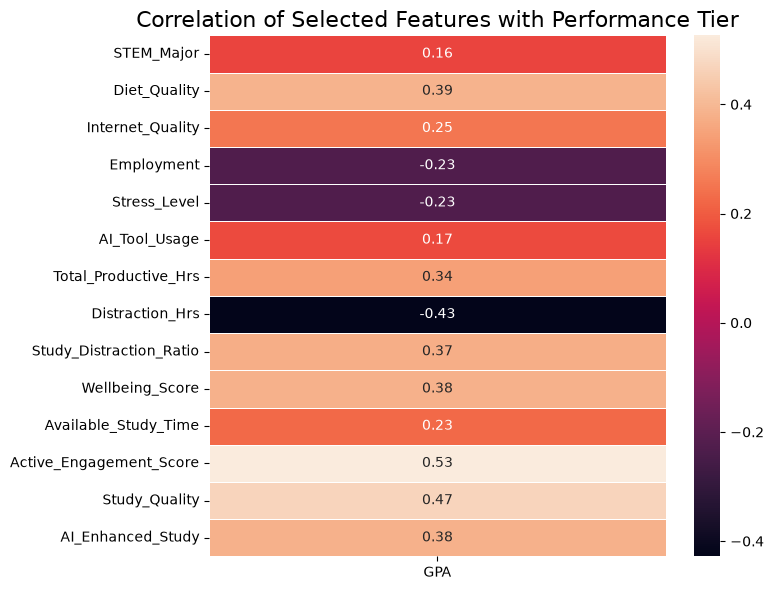

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
# ✅ use X_selector (the SelectKBest object), not X_selected_train (the array)
selected_mask = X_selector.get_support()
selected_features = X_train.columns[selected_mask]

# Rebuild as DataFrame and add target
df_selected = pd.DataFrame(X_selected_train, columns=selected_features)
df_selected['GPA'] = y_train.values

# Plot correlation with Performance_Tier only
plt.figure(figsize=(8, 6))
corr = df_selected.corr()[['GPA']].drop('GPA')
sns.heatmap(corr,annot=True, linewidth=.5)
plt.title('Correlation of Selected Features with Performance Tier', fontsize=16)
plt.tight_layout()
plt.show()

In [18]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Random Forest': RandomForestRegressor(max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(max_depth=10, random_state=42, learning_rate=0.1),
    'XGBoost': XGBRegressor(learning_rate=0.1, random_state=42)
}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    score = model.score(X_test_scaled, y_test)
    print(f"{name}: R^2 Score = {score:.4f}")

Linear Regression: R^2 Score = 0.5085
Ridge Regression: R^2 Score = 0.5085
Lasso Regression: R^2 Score = -0.0001
Random Forest: R^2 Score = 0.4326
Gradient Boosting: R^2 Score = 0.1394
XGBoost: R^2 Score = 0.3756
